**Problem statement**

The objective of this project is to develop a deep learning-based system for the automated detection of pneumonia from chest X-ray images. Pneumonia is a serious lung infection that can be life-threatening if not diagnosed early. Manual diagnosis by radiologists can be time-consuming and may be prone to human error, especially in high-volume healthcare settings.

In this work, we aim to build a Convolutional Neural Network (CNN) model using transfer learning to classify chest X-ray images into two categories: Normal and Pneumonia. The model takes a preprocessed X-ray image as input and outputs the probability of the presence of pneumonia.

This system can assist healthcare professionals by providing quick and accurate preliminary screening, thereby improving diagnostic efficiency and supporting early treatment decisions, particularly in resource-limited environments.

**Approach**

The proposed approach involves using a Convolutional Neural Network (CNN) with transfer learning to classify chest X-ray images. The input images are first preprocessed through resizing and normalization, along with data augmentation to improve generalization. A pretrained MobileNetV2 model is used as a feature extractor, followed by fully connected layers for classification. The model is trained using binary crossentropy loss and optimized with the Adam optimizer. Regularization techniques such as dropout and data augmentation are applied to reduce overfitting. Finally, the model is evaluated using accuracy, confusion matrix, and classification metrics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

In [37]:
base_path = "/content/drive/MyDrive/chest_xray"

In [38]:
train_dir = base_path + "/train"
val_dir   = base_path + "/val"
test_dir  = base_path + "/test"

In [39]:
import os

print(os.listdir(train_dir))

['NORMAL', 'PNEUMONIA']


In [40]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [41]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [42]:
from tensorflow.keras import regularizers

In [43]:
model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [44]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [45]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

In [46]:
steps_per_epoch = 600 // BATCH_SIZE
validation_steps = 200 // BATCH_SIZE

In [47]:
"""history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)"""
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=10
)

Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.6115 - loss: 0.9051 - val_accuracy: 0.5000 - val_loss: 0.7878
Epoch 2/10
 1/37 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8125 - loss: 0.7518

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


37/37 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7872 - loss: 0.6830 - val_accuracy: 0.5000 - val_loss: 0.7792
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.8294 - loss: 0.6092 - val_accuracy: 0.5000 - val_loss: 0.7283
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.8547 - loss: 0.5668 - val_accuracy: 0.5000 - val_loss: 0.7164
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8851 - loss: 0.5022 - val_accuracy: 0.6875 - val_loss: 0.6924
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.8733 - loss: 0.5129 - val_accuracy: 0.8125 - val_loss: 0.6519
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8885 - loss: 0.4764 - val_accuracy: 0.8750 - val_loss: 0.6463
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9088 - loss: 0.4540 - val_accuracy: 0.8750 - val_loss: 0.5977
Epoch 9/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 35s 923ms/step - accuracy: 0.9021 - loss: 0.4541 - val_accuracy: 0.8750 - val_loss: 0.6093


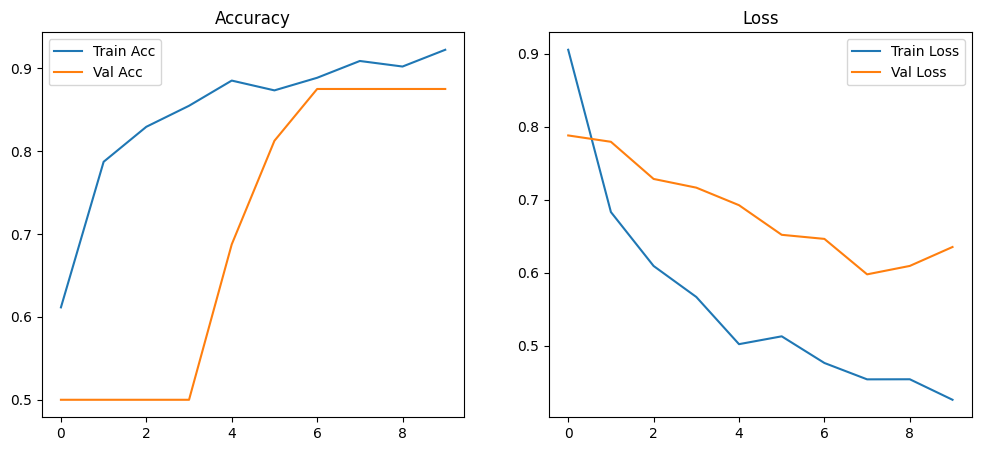

In [49]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [50]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 154ms/step - accuracy: 0.8574 - loss: 0.5364
Test Accuracy: 0.8573718070983887


In [52]:
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)

y_true = test_generator.classes

39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step


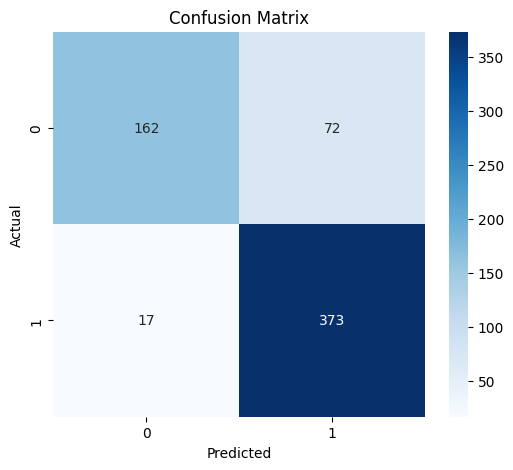

In [57]:
y_true = test_generator.classes
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [58]:
print(classification_report(y_true, y_pred, target_names=['Normal','Pneumonia']))

              precision    recall  f1-score   support

      Normal       0.91      0.69      0.78       234
   Pneumonia       0.84      0.96      0.89       390

    accuracy                           0.86       624
   macro avg       0.87      0.82      0.84       624
weighted avg       0.86      0.86      0.85       624



1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


/tmp/ipykernel_1274/2810938840.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Pred: {class_labels[int(pred[0]>0.5)]}")


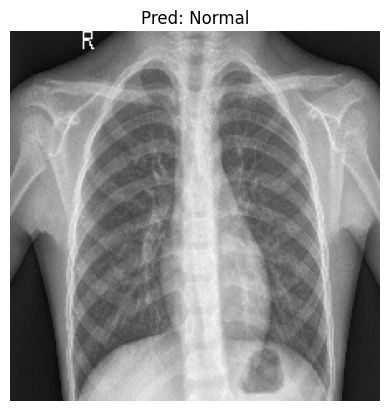

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


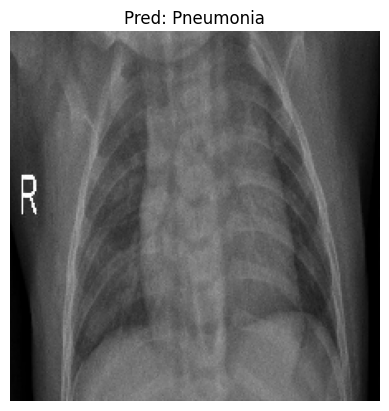

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


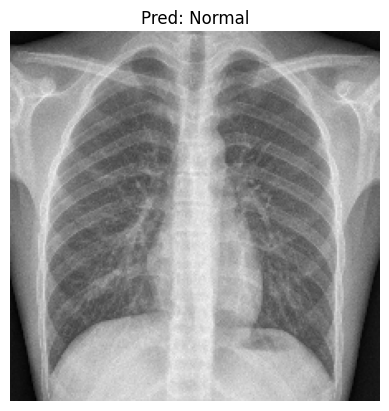

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


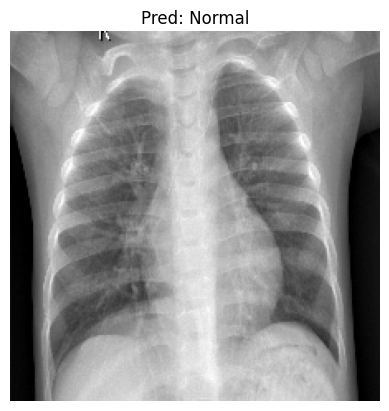

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


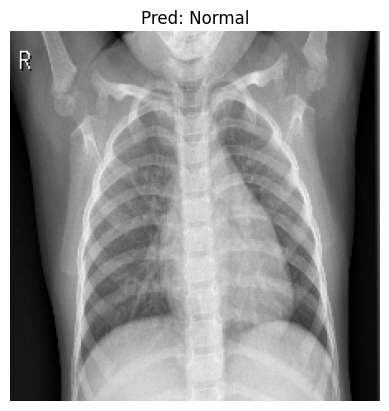

In [55]:
class_labels = ['Normal', 'Pneumonia']

for i in range(5):
    img, label = test_generator[i]
    pred = model.predict(img)

    plt.imshow(img[0])
    plt.title(f"Pred: {class_labels[int(pred[0]>0.5)]}")
    plt.axis('off')
    plt.show()

In [59]:
model.save("/content/drive/MyDrive/pneumonia_model.h5")

In [60]:
!pip install gradio

In [61]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

In [62]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/pneumonia_model.h5"
)

In [63]:
IMG_SIZE = 224

def predict(image):
    # Resize
    img = image.resize((IMG_SIZE, IMG_SIZE))

    # Convert to array
    img = np.array(img) / 255.0

    # Expand dims
    img = np.expand_dims(img, axis=0)

    # Predict
    pred = model.predict(img)[0][0]

    if pred > 0.5:
        label = "PNEUMONIA"
        confidence = float(pred)
    else:
        label = "NORMAL"
        confidence = float(1 - pred)

    return f"{label} (Confidence: {confidence*100:.2f}%)"

In [64]:
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Textbox(label="Prediction"),
    title="🩺 Pneumonia Detection System",
    description="Upload a chest X-ray image to detect Pneumonia"
)

In [65]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8ee970dc9e6ffc2098.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


The proposed deep learning model was trained using a Convolutional Neural Network with transfer learning to classify chest X-ray images into Normal and Pneumonia categories. The training accuracy shows a steady increase over epochs, indicating that the model successfully learns patterns from the training data. However, the validation accuracy is comparatively lower and shows fluctuations, suggesting mild overfitting due to limited dataset size.

The loss curves indicate that the training loss decreases consistently, while the validation loss does not decrease at the same rate, further confirming the presence of overfitting. This behavior is expected since the model is trained on a relatively small subset of data.

The confusion matrix demonstrates that the model is able to correctly classify a majority of the samples, with some misclassifications between Normal and Pneumonia cases. The classification report provides metrics such as precision, recall, and F1-score, which indicate that the model performs reasonably well in distinguishing between the two classes.

Overall, the model achieves satisfactory performance and is capable of identifying pneumonia from chest X-ray images. With additional data and further tuning, the model’s generalization ability can be improved.